# 09 — Modélisation : SVM (Support Vector Machine)

**Objectif** : entraîner et optimiser un SVM pour la détection d'anomalies CBC, sur les deux configurations de features (Expérience A : 9 features, Expérience B1 : 5 features).

**Contrainte computationnelle majeure** : la complexité d'entraînement de SVM croît environ en O(n²) à O(n³) avec le nombre de lignes. Avec ~419K lignes en train, un entraînement complet est irréaliste en temps. On utilise donc le **même sous-échantillon stratifié de 25 000 lignes** que pour KNN (étape 6), pour rester cohérent et exploitable en temps raisonnable. Le test set reste complet pour une évaluation fidèle.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import time
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from evaluation import evaluate_model, plot_confusion_matrices, results_table

os.makedirs('../models', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

RANDOM_STATE = 42

## 0. Chargement des données préparées (issues de l'étape 4)

In [2]:
X_train_A = pd.read_csv('../data/processed/X_train_A.csv')
X_test_A  = pd.read_csv('../data/processed/X_test_A.csv')
y_train_A = pd.read_csv('../data/processed/y_train_A.csv').squeeze()
y_test_A  = pd.read_csv('../data/processed/y_test_A.csv').squeeze()

X_train_B1 = pd.read_csv('../data/processed/X_train_B1.csv')
X_test_B1  = pd.read_csv('../data/processed/X_test_B1.csv')
y_train_B1 = pd.read_csv('../data/processed/y_train_B1.csv').squeeze()
y_test_B1  = pd.read_csv('../data/processed/y_test_B1.csv').squeeze()

print("Expérience A :", X_train_A.shape, X_test_A.shape)
print("Expérience B1:", X_train_B1.shape, X_test_B1.shape)

Expérience A : (419075, 9) (104769, 9)
Expérience B1: (419075, 5) (104769, 5)


## 1. Sous-échantillonnage stratifié du train set

Même principe et même taille que pour KNN (étape 6), pour rendre l'entraînement et le tuning de SVM exploitables en temps raisonnable.

In [3]:
SAMPLE_SIZE = 25000

def stratified_sample(X, y, n, random_state=RANDOM_STATE):
    """Sous-échantillonne X, y en conservant les proportions de classes."""
    if n >= len(X):
        return X, y
    X_sample, _, y_sample, _ = train_test_split(
        X, y, train_size=n, stratify=y, random_state=random_state
    )
    return X_sample, y_sample

X_train_A_svm, y_train_A_svm = stratified_sample(X_train_A, y_train_A, SAMPLE_SIZE)
X_train_B1_svm, y_train_B1_svm = stratified_sample(X_train_B1, y_train_B1, SAMPLE_SIZE)

print("Échantillon Exp A :", X_train_A_svm.shape,
      "| proportions:", y_train_A_svm.value_counts(normalize=True).to_dict())
print("Échantillon Exp B1:", X_train_B1_svm.shape,
      "| proportions:", y_train_B1_svm.value_counts(normalize=True).to_dict())

Échantillon Exp A : (25000, 9) | proportions: {0: 0.7138, 1: 0.2862}
Échantillon Exp B1: (25000, 5) | proportions: {0: 0.7138, 1: 0.2862}


## 2. Baseline — SVM avec paramètres par défaut (kernel rbf, C=1)

In [4]:
svm_A_baseline = SVC(random_state=RANDOM_STATE)
model_A_base, y_pred_A_base, metrics_A_base = evaluate_model(
    svm_A_baseline, X_train_A_svm, y_train_A_svm, X_test_A, y_test_A,
    "SVM baseline - Exp A"
)

svm_B1_baseline = SVC(random_state=RANDOM_STATE)
model_B1_base, y_pred_B1_base, metrics_B1_base = evaluate_model(
    svm_B1_baseline, X_train_B1_svm, y_train_B1_svm, X_test_B1, y_test_B1,
    "SVM baseline - Exp B1"
)

results_table([metrics_A_base, metrics_B1_base])

,Modèle,Accuracy,Precision,Recall,F1-score,Temps (s)
0,SVM baseline - Exp A,0.935697,0.905809,0.865299,0.885091,13.98
1,SVM baseline - Exp B1,0.845594,0.761952,0.669735,0.712873,15.22


## 3. Recherche d'hyperparamètres — GridSearchCV (Expérience A)

Grille testée :
- `C` : tolérance aux erreurs (marge large vs étroite)
- `kernel` : `'linear'` ou `'rbf'`
- `gamma` : influence locale des points (pour kernel rbf uniquement)

Grille volontairement compacte (SVM reste l'algorithme le plus lent même sur l'échantillon réduit).

In [5]:
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
]

grid_svm_A = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE),
    param_grid=param_grid_svm,
    scoring='f1',
    cv=3,                 # cv réduit à 3 pour limiter le temps de calcul
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_svm_A.fit(X_train_A_svm, y_train_A_svm)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp A):", grid_svm_A.best_params_)
print("Meilleur F1-score (CV, Exp A):", grid_svm_A.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Temps de recherche: 165.4s

Meilleurs paramètres (Exp A): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Meilleur F1-score (CV, Exp A): 0.8977409676293369


## 4. Recherche d'hyperparamètres — GridSearchCV (Expérience B1)

In [6]:
grid_svm_B1 = GridSearchCV(
    estimator=SVC(random_state=RANDOM_STATE),
    param_grid=param_grid_svm,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_svm_B1.fit(X_train_B1_svm, y_train_B1_svm)
print(f"Temps de recherche: {time.time()-start:.1f}s")

print("\nMeilleurs paramètres (Exp B1):", grid_svm_B1.best_params_)
print("Meilleur F1-score (CV, Exp B1):", grid_svm_B1.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Temps de recherche: 196.6s

Meilleurs paramètres (Exp B1): {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Meilleur F1-score (CV, Exp B1): 0.7184617100244451


## 5. Évaluation finale des meilleurs modèles sur le TEST set (complet)

In [7]:
best_svm_A = grid_svm_A.best_estimator_
best_svm_B1 = grid_svm_B1.best_estimator_

start = time.time()
y_pred_A = best_svm_A.predict(X_test_A)
print(f"Prédiction Exp A: {time.time()-start:.1f}s")

start = time.time()
y_pred_B1 = best_svm_B1.predict(X_test_B1)
print(f"Prédiction Exp B1: {time.time()-start:.1f}s")

results = []
for name, y_true, y_pred in [
    ("SVM baseline - Exp A", y_test_A, y_pred_A_base),
    ("SVM optimisé - Exp A", y_test_A, y_pred_A),
    ("SVM baseline - Exp B1", y_test_B1, y_pred_B1_base),
    ("SVM optimisé - Exp B1", y_test_B1, y_pred_B1),
]:
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
    })

df_results = results_table(results)
df_results

Prédiction Exp A: 78.2s
Prédiction Exp B1: 280.8s


,Modèle,Accuracy,Precision,Recall,F1-score
0,SVM baseline - Exp A,0.935697,0.905809,0.865299,0.885091
1,SVM optimisé - Exp A,0.943953,0.915469,0.885976,0.900481
2,SVM baseline - Exp B1,0.845594,0.761952,0.669735,0.712873
3,SVM optimisé - Exp B1,0.845594,0.761952,0.669735,0.712873


## 6. Matrices de confusion (baseline vs optimisé, A vs B1)

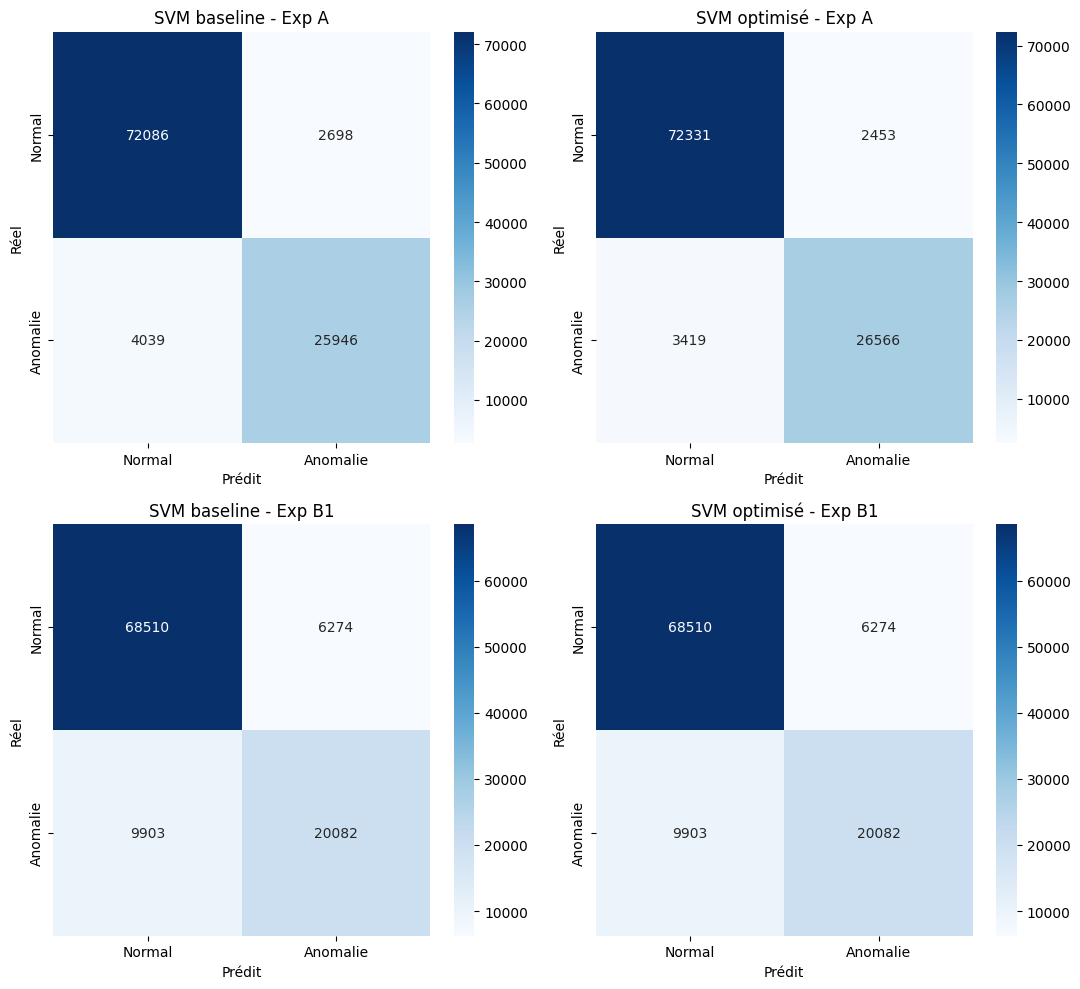

In [8]:
configs = [
    (y_test_A, y_pred_A_base, "SVM baseline - Exp A"),
    (y_test_A, y_pred_A, "SVM optimisé - Exp A"),
    (y_test_B1, y_pred_B1_base, "SVM baseline - Exp B1"),
    (y_test_B1, y_pred_B1, "SVM optimisé - Exp B1"),
]

plot_confusion_matrices(configs, save_path='../figures/confusion_matrices_svm.png')

## 7. Coefficients (uniquement si kernel='linear' a été retenu)

Avec un kernel `rbf`, il n'y a pas de coefficients interprétables directement (la séparation se fait dans un espace projeté implicite). On affiche les coefficients seulement si le meilleur modèle utilise un kernel linéaire.

In [9]:
if best_svm_A.kernel == 'linear':
    coef_A = pd.DataFrame({
        'Variable': X_train_A.columns,
        'Coefficient': best_svm_A.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    print("Coefficients SVM linéaire (Expérience A):")
    print(coef_A)
else:
    print(f"Kernel retenu pour Exp A: '{best_svm_A.kernel}' — pas de coefficients linéaires interprétables.")

print()

if best_svm_B1.kernel == 'linear':
    coef_B1 = pd.DataFrame({
        'Variable': X_train_B1.columns,
        'Coefficient': best_svm_B1.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    print("Coefficients SVM linéaire (Expérience B1):")
    print(coef_B1)
else:
    print(f"Kernel retenu pour Exp B1: '{best_svm_B1.kernel}' — pas de coefficients linéaires interprétables.")

Kernel retenu pour Exp A: 'rbf' — pas de coefficients linéaires interprétables.

Kernel retenu pour Exp B1: 'rbf' — pas de coefficients linéaires interprétables.


## 8. Sauvegarde des modèles et résultats

In [10]:
joblib.dump(best_svm_A, '../models/svm_A_best.pkl')
joblib.dump(best_svm_B1, '../models/svm_B1_best.pkl')

df_results.to_csv('../data/processed/results_svm.csv', index=False)
print("✅ Modèles et résultats SVM sauvegardés")

✅ Modèles et résultats SVM sauvegardés


## Ce qu'il faut analyser pour le rapport

1. **Kernel retenu** : `linear` ou `rbf` ? Si `rbf` est retenu avec un gain notable sur `linear`, cela confirme une frontière de décision non-linéaire (cohérent avec ce qu'on a pu observer avec KNN).
2. **Mention explicite de la limitation computationnelle** : préciser dans le rapport que SVM a été entraîné sur un sous-échantillon de 25 000 lignes (train) pour des raisons de temps de calcul, mais évalué sur le test set complet.
3. **Comparaison avec KNN** : les deux modèles partagent le même échantillon d'entraînement réduit — comparaison directe et équitable possible.
4. **Performance Exp A vs B1** : vérifier si l'écart est cohérent avec les autres algorithmes (confirmation supplémentaire de l'effet du data leakage).